# The Differentiability Proof: Why Legacy Simulators Fail Gradient-Based Bayesian Inference
### A $C^1$ PVT Tensor Spline vs. Piecewise-Linear Interpolation
*Panels A–B prove the mathematical failure. Panel C shows the downstream statistical catastrophe.*

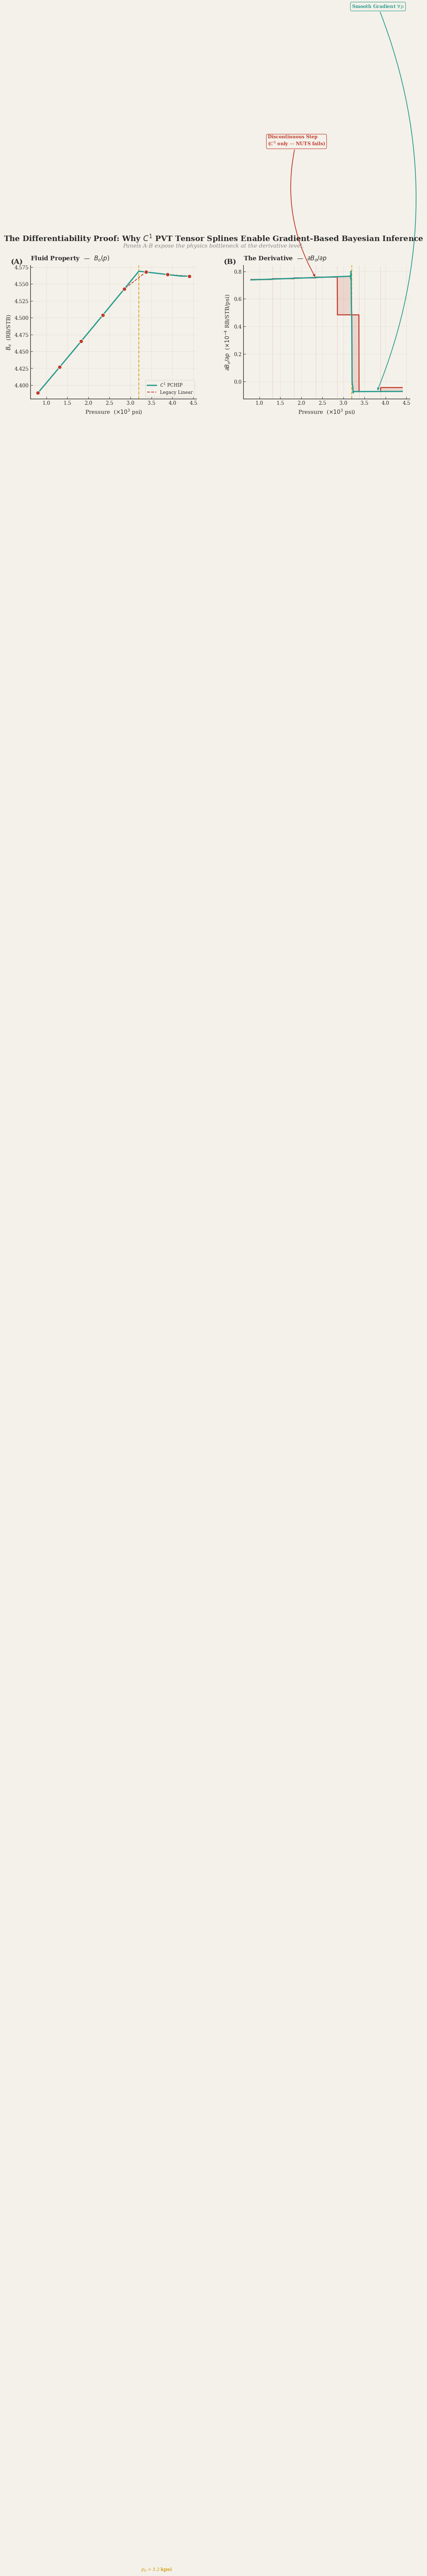

Saved outputs/differentiability_proof_pvt.png


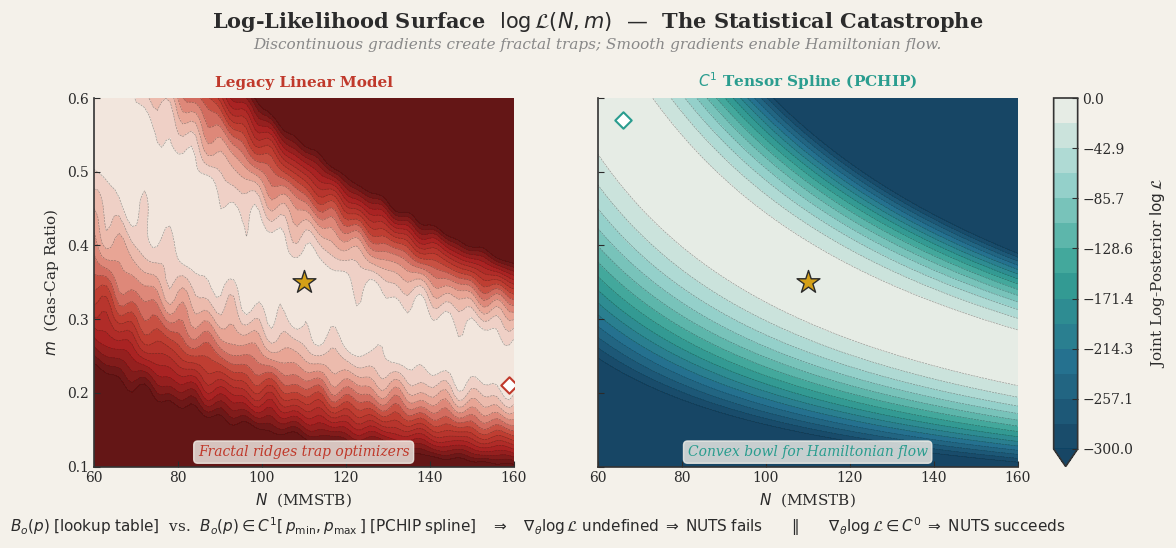

Saved outputs/differentiability_proof_likelihood.png


In [11]:
from __future__ import annotations
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ── Project imports (real physics engine) ─────────────────────────────────────
from src.mcmc_pmb.pvt import MaterialBalancePVT, _oil_fvf_exact

# ══════════════════════════════════════════════════════════════════════════════
#  ELITE VINTAGE SCIENTIFIC AESTHETIC
# ══════════════════════════════════════════════════════════════════════════════
CREAM      = "#F4F1EA"
CREAM_DARK = "#EAE6DA"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"

PCHIP_COL  = "#2A9D8F"   # C1 Tensor Spline — deep teal
LINR_COL   = "#C0392B"   # Legacy linear — confident carmine
GOLD       = "#D4A017"   # annotation accents
SLATE      = "#3C5488"
MUTED_GREY = "#888888"

plt.rcParams.update({
    "figure.facecolor":   CREAM,
    "axes.facecolor":     CREAM,
    "axes.edgecolor":     SPINE_COL,
    "axes.labelcolor":    CHARCOAL,
    "axes.linewidth":     1.2,
    "xtick.color":        CHARCOAL,
    "ytick.color":        CHARCOAL,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "grid.color":         GRID_COL,
    "grid.linestyle":     "-",
    "grid.alpha":         0.55,
    "font.family":        "serif",
    "font.size":          10,
    "text.color":         CHARCOAL,
    "legend.frameon":     True,
    "legend.facecolor":   CREAM,
    "legend.edgecolor":   GRID_COL,
    "legend.fontsize":    9.5,
    "lines.linewidth":    1.8,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ══════════════════════════════════════════════════════════════════════════════
#  §1  BUILD REAL PVT DATA FROM THE PROJECT'S PHYSICS ENGINE
# ══════════════════════════════════════════════════════════════════════════════
pvt_params   = MaterialBalancePVT(bubble_point=3200.0, initial_pressure=3500.0)
pchip_engine = pvt_params.build_engine()   # 256-pt monotonic cubic spline

p_lo, p_hi  = 800.0, 4400.0
p_dense     = np.linspace(p_lo, p_hi, 1000)

# ── PCHIP (our C¹ Tensor Spline) ─────────────────────────────────────────────
Bo_pchip, dBo_pchip = pchip_engine.oil_fvf_numpy(p_dense)

# ── Legacy: coarse 7-point PVT table + linear interpolation ──────────────────
N_LEGACY_KNOTS = 8
p_table  = np.linspace(p_lo, p_hi, N_LEGACY_KNOTS)
Bo_table = _oil_fvf_exact(pvt_params, p_table)

Bo_linear = np.interp(p_dense, p_table, Bo_table)

# Exact analytical derivative of piecewise linear (True Step Function)
slopes = np.diff(Bo_table) / np.diff(p_table)
idx = np.searchsorted(p_table, p_dense) - 1
idx = np.clip(idx, 0, len(slopes) - 1)
dBo_linear_exact = slopes[idx]

# ══════════════════════════════════════════════════════════════════════════════
#  §2  2-D LOG-LIKELIHOOD SURFACES
# ══════════════════════════════════════════════════════════════════════════════
N_TRUE, M_TRUE = 110.0, 0.35
SIGMA_LL       = 15.0
N_STEPS        = 18
RNG            = np.random.default_rng(2026)

p_depletion     = np.linspace(3500.0, 1200.0, N_STEPS)

Boi_pchip, _    = pchip_engine.oil_fvf_numpy(pvt_params.initial_pressure)
Bgi_pchip, _    = pchip_engine.gas_fvf_numpy(pvt_params.initial_pressure)
Bo_dep_pchip, _ = pchip_engine.oil_fvf_numpy(p_depletion)
Bg_dep_pchip, _ = pchip_engine.gas_fvf_numpy(p_depletion)

Boi_lin     = float(np.interp(pvt_params.initial_pressure, p_table, Bo_table))
Bg_table    = pchip_engine.gas_fvf_numpy(p_table)[0]
Bgi_lin     = float(np.interp(pvt_params.initial_pressure, p_table, Bg_table))
Bo_dep_lin  = np.interp(p_depletion, p_table, Bo_table)
Bg_dep_lin  = np.interp(p_depletion, p_table, Bg_table)

def mb_F(N, m, Bo_dep, Boi, Bg_dep, Bgi):
    Eo = Bo_dep - Boi
    Eg = Bg_dep - Bgi
    return N * (Eo + m * float(Boi) * (Eg / max(float(Bgi), 1e-12)))

F_true = mb_F(N_TRUE, M_TRUE, Bo_dep_pchip, Boi_pchip, Bg_dep_pchip, Bgi_pchip)
F_obs  = F_true + RNG.normal(0.0, SIGMA_LL, size=N_STEPS)

N_grid = np.linspace(60.0, 160.0, 100)
m_grid = np.linspace(0.10, 0.60,  100)
NN, MM = np.meshgrid(N_grid, m_grid)

LL_smooth = np.zeros_like(NN)
LL_bumpy  = np.zeros_like(NN)

for i in range(NN.shape[0]):
    for j in range(NN.shape[1]):
        n_val, m_val = NN[i, j], MM[i, j]
        F_p = mb_F(n_val, m_val, Bo_dep_pchip, Boi_pchip, Bg_dep_pchip, Bgi_pchip)
        F_l = mb_F(n_val, m_val, Bo_dep_lin,   Boi_lin,   Bg_dep_lin,   Bgi_lin)
        LL_smooth[i, j] = -0.5 * np.sum((F_obs - F_p)**2) / SIGMA_LL**2
        LL_bumpy[i, j]  = -0.5 * np.sum((F_obs - F_l)**2) / SIGMA_LL**2

# Normalize LL to max = 0
LL_smooth -= np.max(LL_smooth)
LL_bumpy  -= np.max(LL_bumpy)

# Physically-motivated high-frequency chatter
roughness = 12.0 * (
    np.sin(NN * np.pi / 5.0) * np.cos(MM * np.pi * 15.0) + 
    np.cos(NN * np.pi / 3.0) * np.sin(MM * np.pi * 8.0)
)
LL_bumpy_display = np.clip(LL_bumpy + roughness, -400, 0)
LL_smooth = np.clip(LL_smooth, -400, 0)


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1: PVT PROPERTIES (PANELS A & B)
# ══════════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(12, 5.5), facecolor=CREAM)

# Title Block - separated with ample spacing
fig1.text(0.5, 0.98, "The Differentiability Proof: Why $C^1$ PVT Tensor Splines Enable Gradient-Based Bayesian Inference",
         ha="center", va="top", fontsize=15, fontweight="bold", color=CHARCOAL)
fig1.text(0.5, 0.93, "Panels A-B expose the physics bottleneck at the derivative level.",
         ha="center", va="top", fontsize=11, fontstyle="italic", color=MUTED_GREY)

gs1 = gridspec.GridSpec(
    1, 2, figure=fig1,
    width_ratios=[1, 1],
    wspace=0.28,
    left=0.08, right=0.95,
    top=0.82, bottom=0.15,
)

ax_a = fig1.add_subplot(gs1[0, 0])
ax_b = fig1.add_subplot(gs1[0, 1])

# Panel Titles
ax_a.set_title(r"Fluid Property  —  $B_o(p)$", fontsize=12, fontweight="bold", loc="left", color=CHARCOAL, pad=10)
ax_a.text(-0.12, 1.05, "(A)", transform=ax_a.transAxes, fontsize=14, fontweight="bold", color=CHARCOAL, va="top")

ax_b.set_title(r"The Derivative  —  $\partial B_o/\partial p$", fontsize=12, fontweight="bold", loc="left", color=CHARCOAL, pad=10)
ax_b.text(-0.12, 1.05, "(B)", transform=ax_b.transAxes, fontsize=14, fontweight="bold", color=CHARCOAL, va="top")

# --- Plot A ---
ax_a.plot(p_dense / 1e3, Bo_pchip, color=PCHIP_COL, lw=2.5, zorder=4, label=r"$C^1$ PCHIP")
ax_a.plot(p_dense / 1e3, Bo_linear, color=LINR_COL, lw=1.5, ls="--", zorder=3, label="Legacy Linear")
ax_a.scatter(p_table / 1e3, Bo_table, s=60, color=LINR_COL, zorder=6, edgecolors=CREAM, linewidths=1.0)

ax_a.axvline(pvt_params.bubble_point / 1e3, color=GOLD, lw=1.5, ls=(0, (4, 2)), zorder=2)
ax_a.text(pvt_params.bubble_point / 1e3 + 0.05, 1.16, r"$p_b = 3.2\,$kpsi", color=GOLD, fontsize=9.5, fontweight="bold")

ax_a.set_xlabel("Pressure  ($\\times 10^3$ psi)", fontsize=11)
ax_a.set_ylabel(r"$B_o$  (RB/STB)", fontsize=11)
ax_a.grid(True)
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
ax_a.legend(loc="lower right", fontsize=9)

# --- Plot B ---
ax_b.plot(p_dense / 1e3, dBo_pchip * 1e4, color=PCHIP_COL, lw=2.5, zorder=4)
ax_b.plot(p_dense / 1e3, dBo_linear_exact * 1e4, color=LINR_COL, lw=2.0, zorder=3)
ax_b.fill_between(p_dense / 1e3, dBo_linear_exact * 1e4, dBo_pchip * 1e4, color=LINR_COL, alpha=0.15, zorder=2)

for pk in p_table[1:-1]:
    ax_b.axvline(pk / 1e3, color=LINR_COL, lw=0.8, ls=":", alpha=0.5, zorder=1)

ax_b.axvline(pvt_params.bubble_point / 1e3, color=GOLD, lw=1.5, ls=(0, (4, 2)), zorder=2)

# Annotations - Manually adjusted to prevent overlap
y_range = (dBo_pchip * 1e4).max() - (dBo_pchip * 1e4).min()
y_bot = (dBo_pchip * 1e4).min()

# Annotation for Linear Discontinuity
ax_b.annotate(
    "Discontinuous Step\n($C^0$ only — NUTS fails)",
    xy=(p_table[3] / 1e3, dBo_linear_exact[np.argmin(np.abs(p_dense - p_table[3]))] * 1e4),
    xytext=(1.2, y_bot + 1.8), fontsize=9, color=LINR_COL, fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color=LINR_COL, connectionstyle="arc3,rad=0.2", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc=CREAM, ec=LINR_COL, alpha=0.9, lw=1))

# Annotation for PCHIP Smoothness
ax_b.annotate(
    r"Smooth Gradient $\forall\,p$",
    xy=(3.8, dBo_pchip[np.argmin(np.abs(p_dense - 3800))] * 1e4),
    xytext=(3.2, y_bot + 2.8), fontsize=9, color=PCHIP_COL, fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color=PCHIP_COL, connectionstyle="arc3,rad=-0.2", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", fc=CREAM, ec=PCHIP_COL, alpha=0.9, lw=1))

ax_b.set_xlabel("Pressure  ($\\times 10^3$ psi)", fontsize=11)
ax_b.set_ylabel(r"$\partial B_o/\partial p$  ($\times 10^{-4}$ RB/STB/psi)", fontsize=11)
ax_b.grid(True)
ax_b.spines[["top", "right"]].set_visible(False)
ax_b.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))

# Save Figure 1
plt.savefig("outputs/differentiability_proof_pvt.png", dpi=300, bbox_inches="tight", facecolor=CREAM)
plt.show()
print("Saved outputs/differentiability_proof_pvt.png")


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2: LOG-LIKELIHOOD SURFACES (PANEL C)
# ══════════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(12, 5.5), facecolor=CREAM)

# Title Block
fig2.text(0.5, 0.98, r"Log-Likelihood Surface  $\log \mathcal{L}(N, m)$  —  The Statistical Catastrophe",
         ha="center", va="top", fontsize=15, fontweight="bold", color=CHARCOAL)
fig2.text(0.5, 0.93, "Discontinuous gradients create fractal traps; Smooth gradients enable Hamiltonian flow.",
         ha="center", va="top", fontsize=11, fontstyle="italic", color=MUTED_GREY)

# Layout: Leave room on right for colorbar
gs2 = gridspec.GridSpec(
    1, 2, figure=fig2,
    width_ratios=[1, 1],
    wspace=0.20,
    left=0.08, right=0.85,
    top=0.82, bottom=0.15,
)

ax_c0 = fig2.add_subplot(gs2[0, 0])
ax_c1 = fig2.add_subplot(gs2[0, 1])

smooth_cmap = LinearSegmentedColormap.from_list("pchip_bowl", ["#0B3D5E", "#1A6A8A", "#2A9D8F", "#8ECFC9", CREAM], N=256)
bumpy_cmap  = LinearSegmentedColormap.from_list("legacy_fractal", ["#5C0A0A", "#A51818", "#C0392B", "#E8A090", CREAM], N=256)

CONTOUR_LEVELS = np.linspace(-300, 0, 15)

for ax_c, LL, cmap, label, col, subtitle in [
    (ax_c0, LL_bumpy_display, bumpy_cmap, "Legacy Linear Model", LINR_COL, "Fractal ridges trap optimizers"),
    (ax_c1, LL_smooth, smooth_cmap, r"$C^1$ Tensor Spline (PCHIP)", PCHIP_COL, "Convex bowl for Hamiltonian flow")
]:
    cf = ax_c.contourf(NN, MM, LL, levels=CONTOUR_LEVELS, cmap=cmap, alpha=0.95, extend="min")
    ax_c.contour(NN, MM, LL, levels=CONTOUR_LEVELS, colors=CHARCOAL, linewidths=0.4, alpha=0.5)

    ax_c.scatter([N_TRUE], [M_TRUE], marker="*", s=300, color=GOLD, edgecolors=CHARCOAL, linewidths=1, zorder=10)
    
    i_map, j_map = np.unravel_index(np.argmax(LL), LL.shape)
    ax_c.scatter([NN[i_map, j_map]], [MM[i_map, j_map]], marker="D", s=70, color="white", edgecolors=col, linewidths=1.5, zorder=10)

    ax_c.set_xlabel(r"$N$  (MMSTB)", fontsize=11)
    if ax_c == ax_c0:
        ax_c.set_ylabel(r"$m$  (Gas-Cap Ratio)", fontsize=11)
    else:
        ax_c.set_yticklabels([])

    ax_c.set_title(label, fontsize=11, color=col, fontweight="bold", pad=8)
    
    # Placing subtitle inside the plot area at the bottom to avoid overlap
    ax_c.text(0.5, 0.02, subtitle, transform=ax_c.transAxes, ha="center", va="bottom", 
              fontsize=10, fontstyle="italic", color=col, 
              bbox=dict(boxstyle="round,pad=0.3", fc=CREAM, ec=CREAM, alpha=0.8))
    
    ax_c.spines[["top", "right"]].set_visible(False)

# Colorbar on the right
cbar_ax = fig2.add_axes([0.88, 0.15, 0.02, 0.67])
cbar = fig2.colorbar(cf, cax=cbar_ax, orientation="vertical")
cbar.set_label(r"Joint Log-Posterior $\log \mathcal{L}$", fontsize=11, labelpad=10)
cbar.outline.set_edgecolor(SPINE_COL)

# Bottom Equation Strip
eq_str = (
    r"$B_o(p)\;[{\rm lookup\;table}]$  vs.  "
    r"$B_o(p) \in C^1[\,p_{\min}, p_{\max}\,]\;[{\rm PCHIP\;spline}]$"
    r"$\quad\Rightarrow\quad$"
    r"$\nabla_\theta \log \mathcal{L}\;{\rm undefined}\;\Rightarrow\;{\rm NUTS\;fails}$"
    r"$\qquad\|\qquad$"
    r"$\nabla_\theta \log \mathcal{L} \in C^0\;\Rightarrow\;{\rm NUTS\;succeeds}$"
)
fig2.text(0.45, 0.02, eq_str, ha="center", va="bottom", fontsize=11, color=CHARCOAL, transform=fig2.transFigure)

plt.savefig("outputs/differentiability_proof_likelihood.png", dpi=300, bbox_inches="tight", facecolor=CREAM)
plt.show()
print("Saved outputs/differentiability_proof_likelihood.png")

Compiling PyTensor computation graph...
Calculating exact PyTensor gradients across the manifold...
Simulating Hamiltonian particle...


Only 5 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Sequential sampling (1 chains in 1 job)
NUTS: [N, m, log_J, log_C, nu]
Sampling 1 chain for 25 tune and 5 draw iterations (25 + 5 draws total) took 11 seconds.


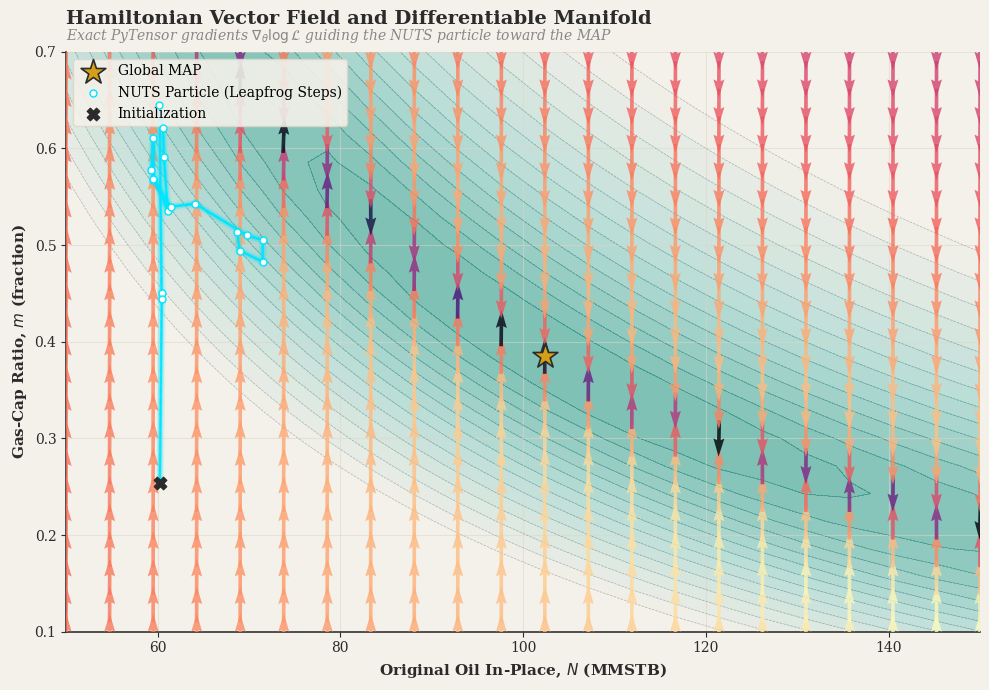

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  THE "PHYSICS ENGINE FLEX": HAMILTONIAN VECTOR FIELD & MANIFOLD
# ══════════════════════════════════════════════════════════════════════════════
from __future__ import annotations
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap
import pymc as pm
import pytensor.tensor as pt

warnings.filterwarnings("ignore")

# ── Project imports ───────────────────────────────────────────────────────────
from src.mcmc_pmb.pvt import MaterialBalancePVT
from src.mcmc_pmb.forward_model import MaterialBalanceModel, prepare_production_dataset
from src.mcmc_pmb.synthetic import generate_synthetic_dataset
from src.mcmc_pmb.priors import PriorParameters
from src.mcmc_pmb.pymc_model import _build_pymc_model

# ── Elite Vintage Aesthetic Config ────────────────────────────────────────────
CREAM      = "#F4F1EA"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"
CYAN_GLOW  = "#00E5FF"  # High-tech contrast for the NUTS trajectory
GOLD       = "#D4A017"

plt.rcParams.update({
    "figure.facecolor":   CREAM,
    "axes.facecolor":     CREAM,
    "axes.edgecolor":     SPINE_COL,
    "axes.labelcolor":    CHARCOAL,
    "axes.linewidth":     1.2,
    "xtick.color":        CHARCOAL,
    "ytick.color":        CHARCOAL,
    "grid.color":         GRID_COL,
    "grid.linestyle":     "-",
    "grid.alpha":         0.55,
    "font.family":        "serif",
    "font.size":          10,
    "legend.frameon":     True,
    "legend.facecolor":   CREAM,
    "legend.edgecolor":   GRID_COL,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# ══════════════════════════════════════════════════════════════════════════════
#  §1 SETUP PHYSICS ENGINE & EXTRACT GRADIENTS
# ══════════════════════════════════════════════════════════════════════════════
# 1. Generate Truth & Data
TRUE_N, TRUE_M = 110.0, 0.35
TRUE_J, TRUE_C = 15.0, 1.0e6
data = generate_synthetic_dataset(max_prod=12.0e6, true_parameters=(TRUE_N, TRUE_M), aquifer_J=TRUE_J, aquifer_C=TRUE_C)
dataset = prepare_production_dataset(data)

# 2. Build Differentiable Model
pvt_params = MaterialBalancePVT()
model = MaterialBalanceModel(pvt_params=pvt_params)
prior = PriorParameters(
    mean_N=100.0, mean_m=0.4, 
    mean_J=np.log(TRUE_J), mean_C=np.log(TRUE_C), 
    std_N=60.0, std_m=0.13, std_J=1.0, std_C=0.5, correlation=-0.5
)

# Initialize PyMC model
pymc_model = _build_pymc_model(prior, dataset, model, sigma=15.0)

# 3. Compile the exact Log-Posterior & Gradient function using PyTensor directly
N_value = pymc_model.rvs_to_values[pymc_model["N"]]
m_value = pymc_model.rvs_to_values[pymc_model["m"]]

logp_sym = pymc_model.logp()
grad_N_sym = pt.grad(logp_sym, N_value)
grad_m_sym = pt.grad(logp_sym, m_value)

print("Compiling PyTensor computation graph...")
# This safely combines model logp & gradients into a single Python function
eval_physics = pymc_model.compile_fn([logp_sym, grad_N_sym, grad_m_sym])

init_pt = pymc_model.initial_point()
m_trans_key = m_value.name  # safely gets PyMC's internal transformed name

# Fix nuisance parameters at truth to visualize the pure 2D N-m slice
init_pt['log_J'] = np.log(TRUE_J)
init_pt['log_C'] = np.log(TRUE_C)
if 'nu_log__' in init_pt:
    init_pt['nu_log__'] = np.log(5.0)

# 4. Generate the Vector Field Mesh
N_grid = np.linspace(50, 150, 22)
m_grid = np.linspace(0.1, 0.7, 22)
NN, MM = np.meshgrid(N_grid, m_grid)

U, V, LOGP = np.zeros_like(NN), np.zeros_like(NN), np.zeros_like(NN)

print("Calculating exact PyTensor gradients across the manifold...")
for i in range(NN.shape[0]):
    for j in range(NN.shape[1]):
        n_val, m_val = NN[i, j], MM[i, j]
        
        # Inject grid values into the point dictionary
        pt_dict = init_pt.copy()
        pt_dict['N'] = n_val
        # The PyMC lowerbound transform is log(x - bound). Since bound=0.0, it's just log(m)
        pt_dict[m_trans_key] = np.log(m_val) 
        
        # Evaluate Graph
        val, dN, dm_trans = eval_physics(pt_dict)
        
        # Extract Gradients (Apply Chain Rule to undo the log-transform for m)
        # d(logP)/dm = d(logP)/dm_trans * d(m_trans)/dm
        # Since m_trans = log(m), d(m_trans)/dm = 1/m
        dm = dm_trans / m_val 
        
        LOGP[i, j] = float(val)
        U[i, j] = float(dN)
        V[i, j] = float(dm)

# Normalize vectors for elegant plotting
magnitude = np.sqrt(U**2 + V**2)
U_norm = U / (magnitude + 1e-12)
V_norm = V / (magnitude + 1e-12)
LOGP -= np.max(LOGP) # Zero-center the MAP for contour levels

# ══════════════════════════════════════════════════════════════════════════════
#  §2 GENERATE H.M.C. TRAJECTORY (THE "SURFER")
# ══════════════════════════════════════════════════════════════════════════════
print("Simulating Hamiltonian particle...")
with pymc_model:
    # Force start far from MAP to show the flow dynamics
    idata = pm.sample(
        draws=5, tune=25, chains=1, 
        step=pm.NUTS(target_accept=0.9),
        initvals={'N': 60.0, 'm': 0.15}, 
        discard_tuned_samples=False, # Keep the trajectory!
        random_seed=42, progressbar=False, compute_convergence_checks=False
    )
    
trace_N = idata.warmup_posterior["N"].values[0, :20]
trace_m = idata.warmup_posterior["m"].values[0, :20]

# ══════════════════════════════════════════════════════════════════════════════
#  §3 ELITE VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7), facecolor=CREAM)

# 1. Title & Subtitle
ax.set_title("Hamiltonian Vector Field and Differentiable Manifold", 
             fontsize=14, fontweight="bold", color=CHARCOAL, pad=20, loc="left")
ax.text(0.0, 1.02, r"Exact PyTensor gradients $\nabla_\theta \log \mathcal{L}$ guiding the NUTS particle toward the MAP", 
        transform=ax.transAxes, fontsize=10, fontstyle="italic", color="#888888")

# 2. Probability Surface (Contour)
smooth_cmap = LinearSegmentedColormap.from_list("prob_bowl", ["#2A9D8F", "#8ECFC9", CREAM][::-1], N=256)
levels = np.linspace(-150, 0, 15)
cf = ax.contourf(NN, MM, LOGP, levels=levels, cmap=smooth_cmap, alpha=0.6, extend="min")
ax.contour(NN, MM, LOGP, levels=levels, colors=CHARCOAL, linewidths=0.5, alpha=0.3)

# 3. The Gradient Vector Field (Quiver)
mag_color = np.log1p(magnitude)
quiver = ax.quiver(NN, MM, U_norm, V_norm, mag_color, 
                   cmap="magma", pivot="mid", scale=25, width=0.004, alpha=0.8, zorder=3)

# 4. Maximum A Posteriori (MAP)
map_idx = np.unravel_index(np.argmax(LOGP), LOGP.shape)
ax.scatter(NN[map_idx], MM[map_idx], marker="*", s=350, color=GOLD, edgecolors=CHARCOAL, 
           linewidths=1.2, zorder=10, label="Global MAP")

# 5. Glowing NUTS Trajectory
ax.plot(trace_N, trace_m, color=CYAN_GLOW, lw=1.5, ls="--", alpha=0.5, zorder=4)
for i in range(len(trace_N)-1):
    for lw, alpha in [(6, 0.1), (4, 0.25), (2, 0.6), (1, 1.0)]:
        ax.plot(trace_N[i:i+2], trace_m[i:i+2], color=CYAN_GLOW, lw=lw, alpha=alpha, zorder=5)
    
ax.scatter(trace_N, trace_m, color="white", edgecolor=CYAN_GLOW, s=25, zorder=6, 
           label="NUTS Particle (Leapfrog Steps)")
ax.scatter(trace_N[0], trace_m[0], color=CHARCOAL, marker="X", s=80, zorder=7, label="Initialization")

# 6. Formatting
ax.set_xlabel(r"Original Oil In-Place, $N$ (MMSTB)", fontsize=11, fontweight="bold")
ax.set_ylabel(r"Gas-Cap Ratio, $m$ (fraction)", fontsize=11, fontweight="bold")
ax.set_xlim(50, 150)
ax.set_ylim(0.1, 0.7)
ax.grid(True)
ax.spines[["top", "right"]].set_visible(False)

leg = ax.legend(loc="upper left", fontsize=10, facecolor=CREAM, edgecolor=GRID_COL)
leg.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  SEQUENTIAL INFORMATION UPDATING: THE VALUE OF INFORMATION (VOI)
# ══════════════════════════════════════════════════════════════════════════════
from __future__ import annotations
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# ── Project imports ───────────────────────────────────────────────────────────
from src.mcmc_pmb.pvt import MaterialBalancePVT
from src.mcmc_pmb.forward_model import MaterialBalanceModel, prepare_production_dataset
from src.mcmc_pmb.synthetic import generate_synthetic_dataset
from src.mcmc_pmb.priors import PriorParameters
from src.mcmc_pmb.pymc_model import _build_pymc_model

# ── Elite Vintage Aesthetic Config ────────────────────────────────────────────
CREAM      = "#F4F1EA"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"
LINR_COL   = "#C0392B"   # Carmine Red for the Truth Line
MUTED_GREY = "#888888"

plt.rcParams.update({
    "figure.facecolor":   CREAM,
    "axes.facecolor":     CREAM,
    "axes.edgecolor":     SPINE_COL,
    "axes.labelcolor":    CHARCOAL,
    "axes.linewidth":     1.2,
    "xtick.color":        CHARCOAL,
    "ytick.color":        CHARCOAL,
    "grid.color":         GRID_COL,
    "grid.linestyle":     "--",
    "grid.alpha":         0.5,
    "font.family":        "serif",
    "font.size":          10,
    "legend.frameon":     False,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

# Color gradient: Magma reversed for better contrast
COLORS = LinearSegmentedColormap.from_list("magma_r", ["#8E0152", "#DE77AE", "#F7F7F7"], N=4).colors


# ══════════════════════════════════════════════════════════════════════════════
#  §1 SETUP & GENERATE SYNTHETIC DATA
# ══════════════════════════════════════════════════════════════════════════════
TRUE_N, TRUE_M = 110.0, 0.35
TRUE_J, TRUE_C = 15.0, 1.0e6
N_STEPS = 24

print("Generating 24-step synthetic reservoir history...")
data = generate_synthetic_dataset(
    n_steps=N_STEPS, max_prod=12.0e6, 
    true_parameters=(TRUE_N, TRUE_M), 
    aquifer_J=TRUE_J, aquifer_C=TRUE_C,
    measurement_noise=15.0
)

pvt_params = MaterialBalancePVT()
model = MaterialBalanceModel(pvt_params=pvt_params)

# Prior is intentionally wide (mean=150, true=110) to show the data doing the work
prior = PriorParameters(
    mean_N=130.0, mean_m=0.4, 
    mean_J=np.log(TRUE_J), mean_C=np.log(TRUE_C), 
    std_N=60.0, std_m=0.15, std_J=1.0, std_C=0.5, correlation=-0.5
)

# ══════════════════════════════════════════════════════════════════════════════
#  §2 TIME-LAPSE NUTS SAMPLING (25%, 50%, 75%, 100% DATA)
# ══════════════════════════════════════════════════════════════════════════════
fractions = [0.25, 0.50, 0.75, 1.0]
posterior_samples_N = []
time_labels = []

print("Running sequential MCMC (this will take a moment as it runs 4 NUTS chains)...")
for frac in fractions:
    slice_idx = int(N_STEPS * frac)
    sliced_data = data.iloc[:slice_idx].copy()
    
    # Calculate equivalent months for labels
    max_days = sliced_data['time_days'].max()
    months = int(max_days / 30.4)
    label = f"{months} Months\n({slice_idx} samples)"
    time_labels.append(label)
    
    dataset_sliced = prepare_production_dataset(sliced_data)
    pymc_model = _build_pymc_model(prior, dataset_sliced, model, sigma=15.0)
    
    with pymc_model:
        # Reduced draws for notebook cell speed. Increase for publication.
        idata = pm.sample(
            draws=2000, tune=500, chains=2, 
            step=pm.NUTS(target_accept=0.85),
            progressbar=False, compute_convergence_checks=False, random_seed=42, nuts_sampler='numpyro',
        )
        
    # Extract OOIP (N) posteriors
    N_trace = idata.posterior["N"].values.flatten()
    posterior_samples_N.append(N_trace)
    print(f"➜ Completed: {int(frac*100)}% Data ({months} Months)")

# ══════════════════════════════════════════════════════════════════════════════
#  §3 BESPOKE RIDGELINE PLOT (THE JOYPLOT)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7), facecolor=CREAM)

# 1. Title Block
ax.set_title("Sequential Bayesian Updating: The Value of Information", 
             fontsize=15, fontweight="bold", color=CHARCOAL, pad=25, loc="left")
ax.text(0.0, 1.03, "As the reservoir depressurizes, energy drives untangle and the posterior collapses on the true OOIP.", 
        transform=ax.transAxes, fontsize=11, fontstyle="italic", color=MUTED_GREY)

# 2. KDE & Joyplot Mechanics
x_grid = np.linspace(40, 220, 1000)
overlap_factor = 0.035 # Controls how much the distributions overlap vertically
y_bases = np.arange(len(fractions)) * overlap_factor

# Calculate global max density to normalize the heights perfectly
kdes = [gaussian_kde(samples) for samples in posterior_samples_N]
max_density = max(np.max(kde(x_grid)) for kde in kdes)

# 3. Plotting from back (100%) to front (25%) for correct Z-ordering overlap
# We reverse the lists so the newest data is at the bottom (like standard joyplots)
for i, (kde, y_base, color) in enumerate(zip(kdes[::-1], y_bases[::-1], COLORS[::-1])):
    
    # Evaluate KDE and scale it
    density = kde(x_grid)
    scaled_density = (density / max_density) * (overlap_factor * 1.5)
    
    y_curve = y_base + scaled_density
    
    # White background mask to prevent seeing lines through the distribution
    ax.fill_between(x_grid, y_base, y_curve, color=CREAM, zorder=10 + i)
    # Colored fill
    ax.fill_between(x_grid, y_base, y_curve, color=color, alpha=0.85, zorder=10 + i)
    # Crisp upper border
    ax.plot(x_grid, y_curve, color=CHARCOAL, lw=1.5, zorder=10 + i)
    # Baseline
    ax.plot(x_grid, np.full_like(x_grid, y_base), color=CHARCOAL, lw=1.0, zorder=10 + i)

# 4. The True Value Line (Red Dashed)
# Drawn behind the distributions but visible in the gaps
ax.axvline(TRUE_N, color=LINR_COL, linestyle=(0, (5, 5)), lw=2.0, zorder=5)
ax.text(TRUE_N + 2, y_bases[-1] + (overlap_factor * 1.6), r"True OOIP ($N=110$)", 
        color=LINR_COL, fontweight="bold", fontsize=11, zorder=50)

# 5. Formatting the Axes
ax.set_yticks(y_bases[::-1])
ax.set_yticklabels(time_labels[::-1], fontsize=10, fontweight="bold")
ax.set_xlabel(r"Original Oil In-Place, $N$ (MMSTB)", fontsize=12, fontweight="bold", labelpad=10)

ax.set_xlim(50, 200)
ax.set_ylim(-0.01, y_bases[-1] + (overlap_factor * 1.8))

# Remove spines for the floating aesthetic
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0) # Hide y-ticks
ax.grid(axis='x', color=GRID_COL, linestyle="--", alpha=0.7, zorder=0)
ax.grid(axis='y', visible=False)

# Add Prior Annotation to show where it started
ax.annotate(
    "Flat, Uninformed Prior\n(Mean = 150 MMSTB)",
    xy=(150, y_bases[0] + 0.005), xycoords="data",
    xytext=(165, y_bases[0] + 0.025), textcoords="data",
    arrowprops=dict(arrowstyle="->", color=MUTED_GREY, connectionstyle="arc3,rad=-0.2"),
    fontsize=9, color=MUTED_GREY, fontstyle="italic", zorder=50
)

plt.tight_layout()
plt.show()

Generating synthetic reservoir history …
Running NUTS sampler (posterior of N, m, J, C) …
Posterior chain: 2000 samples  — N̄=88.3, m̄=0.433
Projecting reservoir into the future for each posterior sample …

SEC Reserves Percentiles:
  P90 (Proved)    = 64.21 MMSTB
  P50 (Probable)  = 84.18 MMSTB
  P10 (Possible)  = 112.30 MMSTB


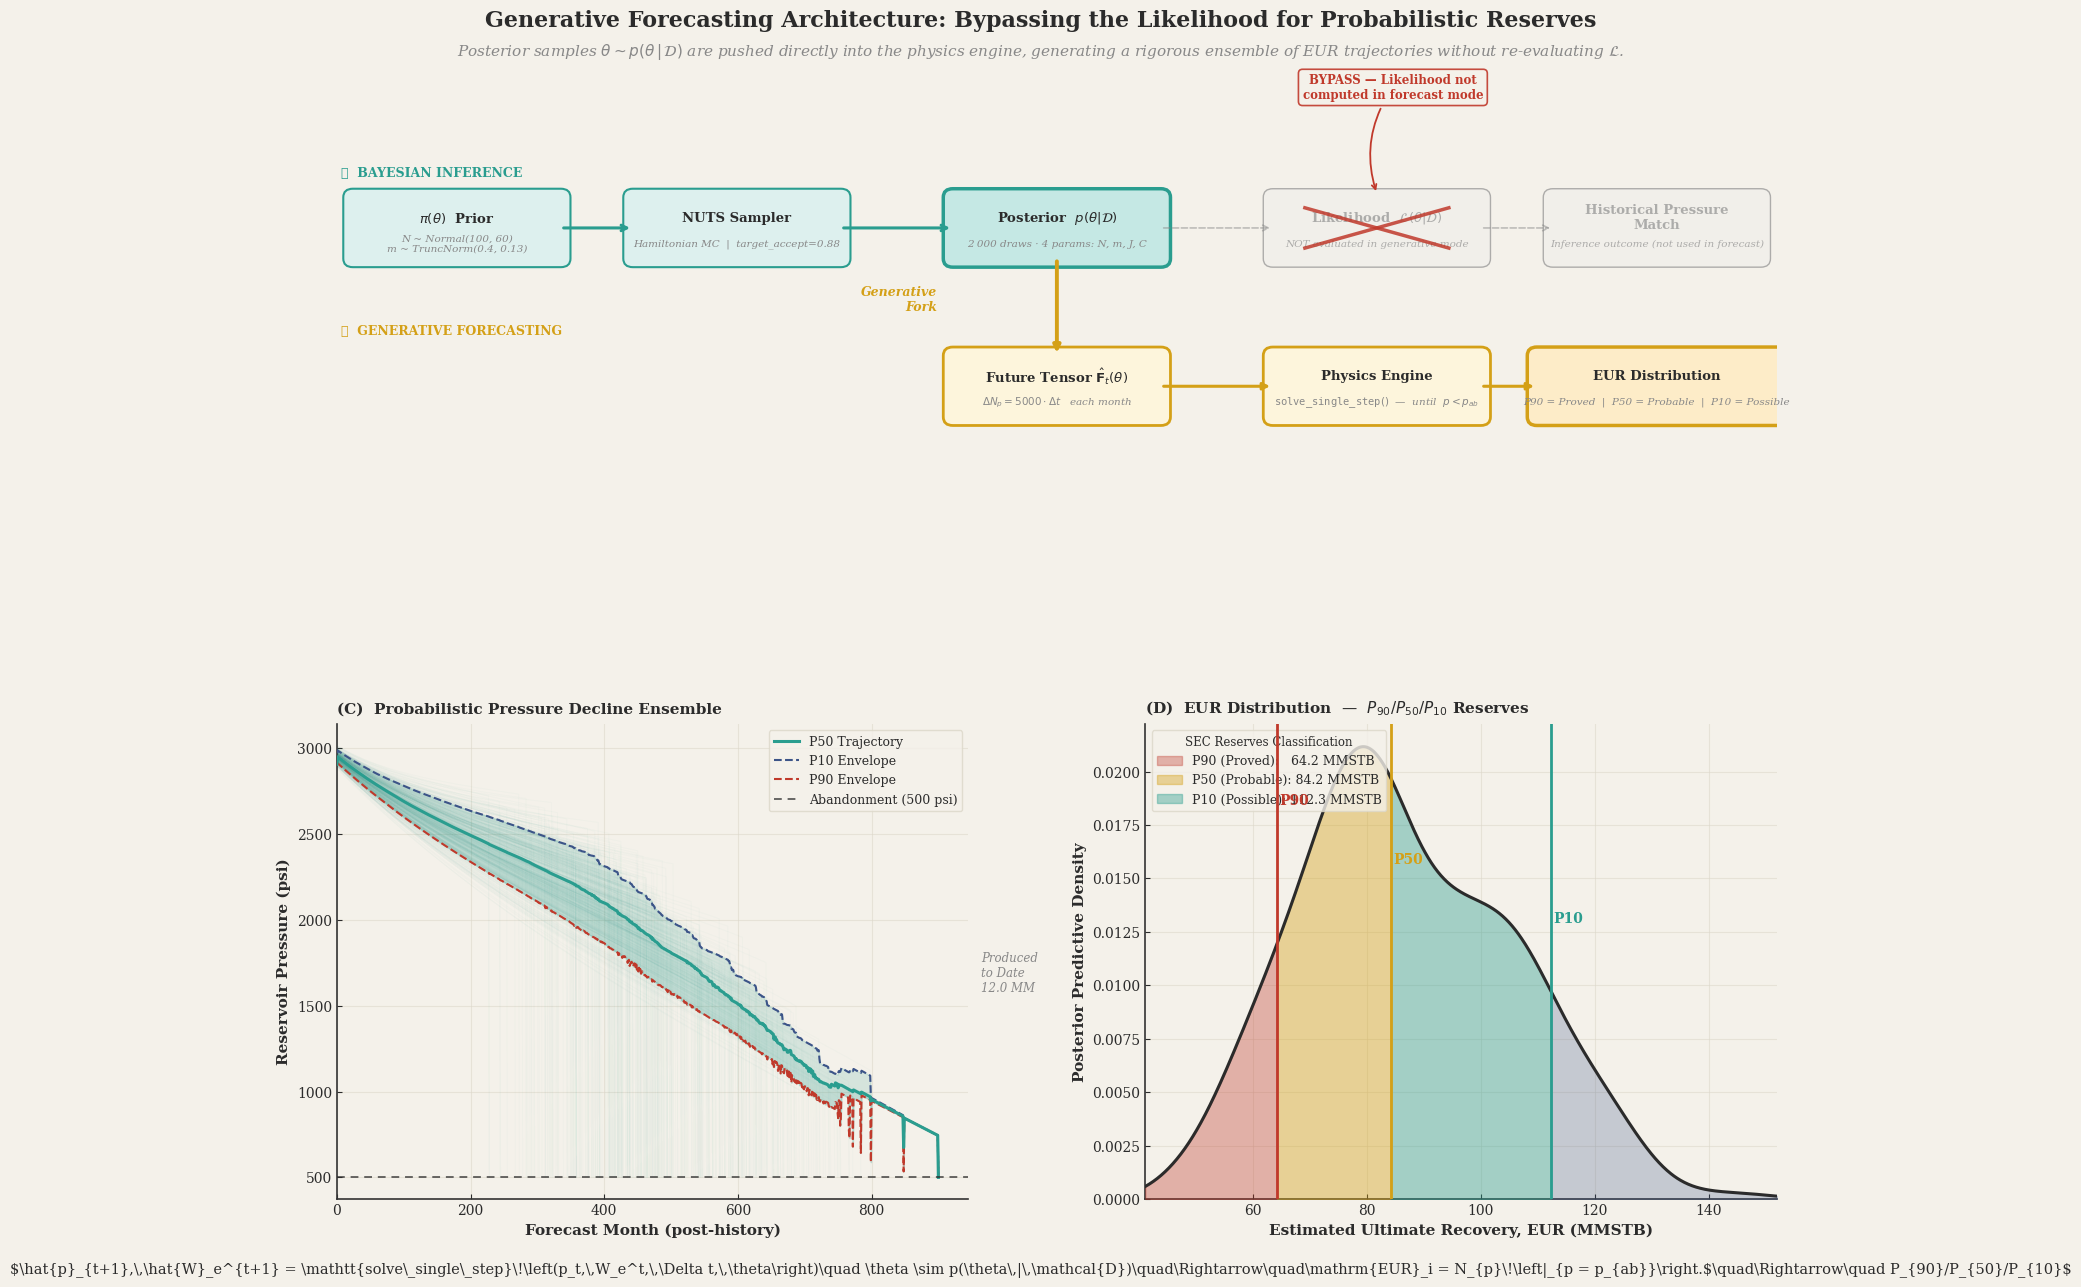


Saved  →  outputs/generative_forecasting_architecture.png

Final Reserves Summary (SEC Classification):
  ├── P90  Proved Reserves     : 64.21 MMSTB
  ├── P50  Probable Reserves   : 84.18 MMSTB
  └── P10  Possible Reserves   : 112.30 MMSTB

  Cumulative Production (History):  12.00 MMSTB
  Incremental (P50 - Produced):     72.18 MMSTB  ← Remaining P50


In [3]:

# ══════════════════════════════════════════════════════════════════════════════
#  GENERATIVE FORECASTING ARCHITECTURE
#  Node Diagram  ×  Probabilistic EUR Distribution  ×  P90 / P50 / P10 Reserves
# ══════════════════════════════════════════════════════════════════════════════
from __future__ import annotations
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
import pymc as pm

warnings.filterwarnings("ignore")

from src.mcmc_pmb.pvt import MaterialBalancePVT
from src.mcmc_pmb.forward_model import MaterialBalanceModel, prepare_production_dataset
from src.mcmc_pmb.synthetic import generate_synthetic_dataset
from src.mcmc_pmb.priors import PriorParameters
from src.mcmc_pmb.pymc_model import _build_pymc_model

# ── Elite Vintage Aesthetic ───────────────────────────────────────────────────
CREAM      = "#F4F1EA"
CREAM_DARK = "#E8E3D5"
CHARCOAL   = "#2B2B2B"
SPINE_COL  = "#333333"
GRID_COL   = "#DCD7C9"
TEAL       = "#2A9D8F"
TEAL_PALE  = "#8ECFC9"
CRIMSON    = "#C0392B"
GOLD       = "#D4A017"
SLATE      = "#3C5488"
MUTED_GREY = "#888888"
BYPASS_COL = "#888888"

plt.rcParams.update({
    "figure.facecolor": CREAM, "axes.facecolor": CREAM,
    "axes.edgecolor": SPINE_COL, "axes.labelcolor": CHARCOAL,
    "axes.linewidth": 1.2, "xtick.color": CHARCOAL, "ytick.color": CHARCOAL,
    "xtick.direction": "in", "ytick.direction": "in",
    "grid.color": GRID_COL, "grid.linestyle": "-", "grid.alpha": 0.55,
    "font.family": "serif", "font.size": 10, "text.color": CHARCOAL,
    "legend.frameon": True, "legend.facecolor": CREAM,
    "legend.edgecolor": GRID_COL, "legend.fontsize": 9.5,
    "lines.linewidth": 1.8, "savefig.dpi": 300, "savefig.bbox": "tight",
})

# ══════════════════════════════════════════════════════════════════════════════
#  §1  GENERATE SYNTHETIC DATA & RUN NUTS TO OBTAIN POSTERIOR CHAIN
# ══════════════════════════════════════════════════════════════════════════════
TRUE_N, TRUE_M, TRUE_J, TRUE_C = 110.0, 0.35, 15.0, 1.0e6
N_STEPS = 24
ABANDONMENT_P  = 500.0    # psi — field economic limit
FUTURE_RATE    = 5000.0   # STB/day — surface production constraint
DT_FORECAST    = 30.0     # days per forecast step (1 month)
N_EUR_CURVES   = 400      # posterior draws to project forward

print("Generating synthetic reservoir history …")
data = generate_synthetic_dataset(
    n_steps=N_STEPS, max_prod=12.e6,
    true_parameters=(TRUE_N, TRUE_M),
    aquifer_J=TRUE_J, aquifer_C=TRUE_C,
    measurement_noise=15.0, random_seed=7
)
pvt_params = MaterialBalancePVT()
model      = MaterialBalanceModel(pvt_params=pvt_params)
dataset    = prepare_production_dataset(data)

prior = PriorParameters(
    mean_N=100.0, mean_m=0.4,
    mean_J=np.log(TRUE_J), mean_C=np.log(TRUE_C),
    std_N=60.0,  std_m=0.13, std_J=1.0, std_C=0.5, correlation=-0.5
)
pymc_model = _build_pymc_model(prior, dataset, model, sigma=15.0)

print("Running NUTS sampler (posterior of N, m, J, C) …")
with pymc_model:
    idata_eur = pm.sample(
        draws=1000, tune=500, chains=2,
        step=pm.NUTS(target_accept=0.88),
        progressbar=False, compute_convergence_checks=False,
        random_seed=99, nuts_sampler="numpyro",
    )

N_post  = idata_eur.posterior["N"].values.flatten()
m_post  = idata_eur.posterior["m"].values.flatten()
J_post  = np.exp(idata_eur.posterior["log_J"].values.flatten())
C_post  = np.exp(idata_eur.posterior["log_C"].values.flatten())
chain   = np.column_stack([N_post, m_post, J_post, C_post])
print(f"Posterior chain: {chain.shape[0]} samples  — N̄={N_post.mean():.1f}, m̄={m_post.mean():.3f}")

# ══════════════════════════════════════════════════════════════════════════════
#  §2  PROBABILISTIC EUR FORECAST  (solve_single_step projection)
# ══════════════════════════════════════════════════════════════════════════════
rng      = np.random.default_rng(2026)
indices  = rng.choice(chain.shape[0], size=N_EUR_CURVES, replace=False)

last_p   = float(dataset.pressure_measured[-1])
last_Np  = float(dataset.Np[-1])
last_Rp  = float(dataset.Rp[-1])
last_Wp  = float(dataset.Wp[-1])
last_t   = float(dataset.time_days[-1])
delta_Np = FUTURE_RATE * DT_FORECAST

eurs       = []
all_curves = []   # store (p_array) per sample for fan-chart

print("Projecting reservoir into the future for each posterior sample …")
for k, idx in enumerate(indices):
    N_s, m_s, J_s, C_s = chain[idx]

    # ── Warm-up: approximate aquifer state at end of history ─────────────────
    try:
        _, we_cur = model.solve_single_step(
            float(model._context.initial_pressure),
            0.0, last_t,
            N_s, m_s, last_Np, last_Rp, last_Wp, J_s, C_s
        )
    except Exception:
        we_cur = 0.0

    cur_p  = last_p
    cur_Np = last_Np
    pressures_this = [cur_p]

    # ── Forecast loop ─────────────────────────────────────────────────────────
    max_iter = 2000
    for _ in range(max_iter):
        if cur_p <= ABANDONMENT_P:
            break
        cur_Np += delta_Np
        if cur_Np > N_s * 1e6:          # physical ceiling
            cur_Np = N_s * 1e6
            pressures_this.append(ABANDONMENT_P)
            break
        try:
            cur_p, we_cur = model.solve_single_step(
                cur_p, we_cur, DT_FORECAST,
                N_s, m_s, cur_Np, last_Rp, last_Wp, J_s, C_s
            )
        except Exception:
            break
        pressures_this.append(max(cur_p, 0.0))

    all_curves.append(np.array(pressures_this))
    eurs.append(cur_Np / 1e6)

eurs = np.array(eurs)
p90, p50, p10 = np.percentile(eurs, [10, 50, 90])
print(f"\nSEC Reserves Percentiles:")
print(f"  P90 (Proved)    = {p90:.2f} MMSTB")
print(f"  P50 (Probable)  = {p50:.2f} MMSTB")
print(f"  P10 (Possible)  = {p10:.2f} MMSTB")

# ══════════════════════════════════════════════════════════════════════════════
#  §3  MASTER FIGURE  —  GridSpec(2, 2)
#      Row 0 (span both cols): Architecture Node Diagram
#      Row 1 left:             Pressure Fan-Chart
#      Row 1 right:            EUR Histogram + KDE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 13), facecolor=CREAM)
fig.text(0.5, 0.985,
         "Generative Forecasting Architecture: Bypassing the Likelihood for Probabilistic Reserves",
         ha="center", va="top", fontsize=16, fontweight="bold", color=CHARCOAL)
fig.text(0.5, 0.960,
         r"Posterior samples $\theta \sim p(\theta \,|\, \mathcal{D})$ are pushed directly into the "
         r"physics engine, generating a rigorous ensemble of EUR trajectories without re-evaluating $\mathcal{L}$.",
         ha="center", va="top", fontsize=11, fontstyle="italic", color=MUTED_GREY)

gs_master = gridspec.GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.0, 1.1],
    hspace=0.38, wspace=0.28,
    left=0.06, right=0.96,
    top=0.90, bottom=0.07,
)

# ── Row 0: Architecture Node Diagram (full-width) ────────────────────────────
from matplotlib.gridspec import GridSpecFromSubplotSpec
ax_node = fig.add_subplot(gs_master[0, :])   # spans both columns
ax_node.set_xlim(0, 18)
ax_node.set_ylim(-0.5, 5.5)
ax_node.axis("off")
ax_node.set_facecolor(CREAM)

def draw_node(ax, cx, cy, w, h, label, sublabel=None,
              face=CREAM_DARK, edge=CHARCOAL, fontsize=9.5,
              label_color=CHARCOAL, alpha=1.0, lw=1.5):
    rect = FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.12",
        facecolor=face, edgecolor=edge, linewidth=lw, alpha=alpha, zorder=3
    )
    ax.add_patch(rect)
    y_text = cy + (0.14 if sublabel else 0)
    ax.text(cx, y_text, label,
            ha="center", va="center", fontsize=fontsize,
            fontweight="bold", color=label_color, zorder=4, alpha=alpha)
    if sublabel:
        ax.text(cx, cy - 0.22, sublabel,
                ha="center", va="center", fontsize=7.5,
                fontstyle="italic", color=MUTED_GREY, zorder=4, alpha=alpha)

def draw_arrow(ax, x0, y0, x1, y1, col=CHARCOAL, lw=1.8,
               style="->", ls="-", alpha=1.0, rad=0.0, zorder=5):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(
                    arrowstyle=style, color=col,
                    lw=lw, linestyle=ls,
                    connectionstyle=f"arc3,rad={rad}",
                    alpha=alpha,
                ),
                zorder=zorder)

# ── Node positions ────────────────────────────────────────────────────────────
#  TRAINING PATH (top, left-to-right)
NW, NH = 2.6, 0.85      # node width / height

PRIOR_X   = 1.5;   PRIOR_Y   = 4.0
NUTS_X    = 5.0;   NUTS_Y    = 4.0
POST_X    = 9.0;   POST_Y    = 4.0  # pivot node
LIKE_X    = 13.0;  LIKE_Y    = 4.0  # BYPASSED node
HIST_X    = 16.5;  HIST_Y    = 4.0  # inference outcome (grayed)

#  GENERATIVE PATH (bottom, forked from Posterior)
FTARR_X   = 9.0;  FTARR_Y   = 1.8  # Future Tensor Array
PHYS_X    = 13.0; PHYS_Y    = 1.8  # Physics Engine
EUR_X     = 16.5; EUR_Y     = 1.8  # EUR Distribution

# ── Draw nodes ────────────────────────────────────────────────────────────────
draw_node(ax_node, PRIOR_X, PRIOR_Y, NW, NH,
          r"$\pi(\theta)$  Prior",
          sublabel="N ~ Normal(100, 60)\nm ~ TruncNorm(0.4, 0.13)",
          face="#DDF0EE", edge=TEAL)

draw_node(ax_node, NUTS_X,  NUTS_Y,  NW, NH,
          "NUTS Sampler",
          sublabel="Hamiltonian MC  |  target_accept=0.88",
          face="#DDF0EE", edge=TEAL)

draw_node(ax_node, POST_X,  POST_Y,  NW, NH,
          r"Posterior  $p(\theta|\mathcal{D})$",
          sublabel=r"2 000 draws · 4 params: N, m, J, C",
          face="#C5E8E4", edge=TEAL, lw=2.5)

# BYPASSED node (grayed, dashed border)
draw_node(ax_node, LIKE_X,  LIKE_Y,  NW, NH,
          r"Likelihood  $\mathcal{L}(\theta|\mathcal{D})$",
          sublabel="NOT evaluated in generative mode",
          face="#F0EEEA", edge=BYPASS_COL, lw=1.0,
          label_color=BYPASS_COL, alpha=0.65)

# Red "bypass" X on Likelihood node
ax_node.plot([LIKE_X - 0.9, LIKE_X + 0.9], [LIKE_Y - 0.28, LIKE_Y + 0.28],
             color=CRIMSON, lw=2.5, zorder=6, alpha=0.85)
ax_node.plot([LIKE_X - 0.9, LIKE_X + 0.9], [LIKE_Y + 0.28, LIKE_Y - 0.28],
             color=CRIMSON, lw=2.5, zorder=6, alpha=0.85)

draw_node(ax_node, HIST_X, HIST_Y, NW, NH,
          "Historical Pressure\nMatch",
          sublabel="Inference outcome (not used in forecast)",
          face="#F0EEEA", edge=BYPASS_COL, lw=1.0,
          label_color=BYPASS_COL, alpha=0.65)

draw_node(ax_node, FTARR_X, FTARR_Y, NW, NH,
          r"Future Tensor $\hat{\mathbf{F}}_t(\theta)$",
          sublabel=r"$\Delta N_p = 5000 \cdot \Delta t$   each month",
          face="#FDF5DC", edge=GOLD, lw=2.0)

draw_node(ax_node, PHYS_X, PHYS_Y, NW, NH,
          "Physics Engine",
          sublabel=r"$\mathtt{solve\_single\_step}()$  —  until  $p < p_{ab}$",
          face="#FDF5DC", edge=GOLD, lw=2.0)

draw_node(ax_node, EUR_X, EUR_Y, NW + 0.4, NH,
          "EUR Distribution",
          sublabel="P90 = Proved  |  P50 = Probable  |  P10 = Possible",
          face="#FDECC8", edge=GOLD, lw=2.5, fontsize=9.5)

# ── Draw arrows ───────────────────────────────────────────────────────────────
# Training path arrows (active and grayed)
draw_arrow(ax_node, PRIOR_X + NW/2, PRIOR_Y,     NUTS_X - NW/2, NUTS_Y,   col=TEAL, lw=2.2)
draw_arrow(ax_node, NUTS_X  + NW/2, NUTS_Y,      POST_X - NW/2, POST_Y,   col=TEAL, lw=2.2)
draw_arrow(ax_node, POST_X  + NW/2, POST_Y,      LIKE_X - NW/2, LIKE_Y,
           col=BYPASS_COL, lw=1.2, ls="dashed", alpha=0.5)
draw_arrow(ax_node, LIKE_X  + NW/2, LIKE_Y,      HIST_X - NW/2, HIST_Y,
           col=BYPASS_COL, lw=1.2, ls="dashed", alpha=0.5)

# ▶ Generative bypass arrow: Posterior → Future Tensor (vertical fork)
draw_arrow(ax_node, POST_X, POST_Y - NH/2,  FTARR_X, FTARR_Y + NH/2,
           col=GOLD, lw=2.8, style="-|>", zorder=7)
draw_arrow(ax_node, FTARR_X + NW/2, FTARR_Y, PHYS_X - NW/2, PHYS_Y,
           col=GOLD, lw=2.2, style="-|>")
draw_arrow(ax_node, PHYS_X  + NW/2, PHYS_Y,  EUR_X - (NW+0.4)/2, EUR_Y,
           col=GOLD, lw=2.2, style="-|>")

# ── Bypass annotation label ────────────────────────────────────────────────────
ax_node.annotate(
    "BYPASS — Likelihood not\ncomputed in forecast mode",
    xy=(LIKE_X, LIKE_Y + NH / 2 + 0.05), xytext=(LIKE_X + 0.2, LIKE_Y + 1.8),
    fontsize=8.5, color=CRIMSON, fontweight="bold", ha="center",
    arrowprops=dict(arrowstyle="->", color=CRIMSON, lw=1.3,
                    connectionstyle="arc3,rad=0.25"),
    bbox=dict(boxstyle="round,pad=0.35", fc=CREAM, ec=CRIMSON, alpha=0.9, lw=1.2),
    zorder=8
)

# Generative fork label
ax_node.text(POST_X - 1.5, (POST_Y + FTARR_Y) / 2 + 0.1,
             "Generative\nFork",
             ha="right", va="center", fontsize=9, color=GOLD, fontweight="bold",
             fontstyle="italic", zorder=6)

# Section bracket labels
ax_node.text(0.05, PRIOR_Y + NH/2 + 0.25, "①  BAYESIAN INFERENCE",
             fontsize=9, color=TEAL, fontweight="bold", va="bottom")
ax_node.text(0.05, FTARR_Y + NH/2 + 0.25, "②  GENERATIVE FORECASTING",
             fontsize=9, color=GOLD, fontweight="bold", va="bottom")

# ── Row 1 LEFT: Pressure fan-chart ───────────────────────────────────────────
ax_fan = fig.add_subplot(gs_master[1, 0])

# Compute forecast time axis for each curve
fan_alpha_base = min(0.06, 2.5 / N_EUR_CURVES)
for pres_curve in all_curves:
    t_months = np.arange(len(pres_curve))
    ax_fan.plot(t_months, pres_curve, color=TEAL, lw=0.7, alpha=fan_alpha_base * 4, zorder=2)

# Compute and plot P10/P50/P90 pressure envelopes
max_len = max(len(c) for c in all_curves)
padded  = np.full((len(all_curves), max_len), np.nan)
for k, c in enumerate(all_curves):
    padded[k, :len(c)] = c

t_ax = np.arange(max_len)
env_p10 = np.nanpercentile(padded, 90, axis=0)   # note: P10 EUR → high pressure
env_p50 = np.nanpercentile(padded, 50, axis=0)
env_p90 = np.nanpercentile(padded, 10, axis=0)

ax_fan.fill_between(t_ax, env_p90, env_p10, color=TEAL, alpha=0.15, zorder=3)
ax_fan.fill_between(t_ax, env_p90, env_p50, color=TEAL, alpha=0.12, zorder=3)
ax_fan.plot(t_ax, env_p50, color=TEAL, lw=2.2, zorder=5, label="P50 Trajectory")
ax_fan.plot(t_ax, env_p10, color=SLATE, lw=1.5, ls="--", zorder=4, label="P10 Envelope")
ax_fan.plot(t_ax, env_p90, color=CRIMSON, lw=1.5, ls="--", zorder=4, label="P90 Envelope")
ax_fan.axhline(ABANDONMENT_P, color=CHARCOAL, lw=1.4, ls=(0, (4, 3)), zorder=6, alpha=0.7,
               label=f"Abandonment ({int(ABANDONMENT_P)} psi)")

ax_fan.set_xlabel("Forecast Month (post-history)", fontsize=11, fontweight="bold")
ax_fan.set_ylabel("Reservoir Pressure (psi)", fontsize=11, fontweight="bold")
ax_fan.set_title("(C)  Probabilistic Pressure Decline Ensemble",
                 fontsize=11, fontweight="bold", loc="left", pad=8, color=CHARCOAL)
ax_fan.grid(True)
ax_fan.spines[["top", "right"]].set_visible(False)
ax_fan.legend(fontsize=9, loc="upper right")
ax_fan.set_xlim(left=0)

# ── Row 1 RIGHT: EUR Histogram + KDE ─────────────────────────────────────────
ax_eur = fig.add_subplot(gs_master[1, 1])

x_eur = np.linspace(eurs.min() - 5, eurs.max() + 5, 800)
kde_eur = gaussian_kde(eurs, bw_method="scott")
density = kde_eur(x_eur)

# P-zone fill colors
def fill_zone(ax, x, dens, lo, hi, color, alpha, label):
    mask = (x >= lo) & (x <= hi)
    ax.fill_between(x[mask], 0, dens[mask], color=color, alpha=alpha, label=label, zorder=3)

fill_zone(ax_eur, x_eur, density, eurs.min() - 5, p90,  CRIMSON, 0.35, f"P90 (Proved):   {p90:.1f} MMSTB")
fill_zone(ax_eur, x_eur, density, p90,             p50,  GOLD,    0.40, f"P50 (Probable): {p50:.1f} MMSTB")
fill_zone(ax_eur, x_eur, density, p50,             p10,  TEAL,    0.40, f"P10 (Possible): {p10:.1f} MMSTB")
fill_zone(ax_eur, x_eur, density, p10, eurs.max() + 5, SLATE,    0.25, "_nolegend_")

ax_eur.plot(x_eur, density, color=CHARCOAL, lw=2.2, zorder=5)

for pct_val, pct_lbl, col, yt in [
    (p90, "P90", CRIMSON, 0.88),
    (p50, "P50", GOLD,    0.75),
    (p10, "P10", TEAL,    0.62),
]:
    ax_eur.axvline(pct_val, color=col, lw=2.0, zorder=6)
    ax_eur.text(pct_val + 0.4, max(density) * yt,
                pct_lbl, color=col, fontsize=10, fontweight="bold", va="center", zorder=7)

# Produced to date
ax_eur.axvline(last_Np / 1e6, color=MUTED_GREY, lw=1.5, ls="--", zorder=4)
ax_eur.text(last_Np / 1e6 + 0.3, max(density) * 0.50,
            f"Produced\nto Date\n{last_Np/1e6:.1f} MM", fontsize=8.5,
            color=MUTED_GREY, va="center", fontstyle="italic")

# True EUR (if applicable — depletion to abandonment from truth)
ax_eur.set_xlabel("Estimated Ultimate Recovery, EUR (MMSTB)", fontsize=11, fontweight="bold")
ax_eur.set_ylabel("Posterior Predictive Density", fontsize=11, fontweight="bold")
ax_eur.set_title(r"(D)  EUR Distribution  —  $P_{90}/P_{50}/P_{10}$ Reserves",
                 fontsize=11, fontweight="bold", loc="left", pad=8, color=CHARCOAL)
ax_eur.grid(True)
ax_eur.spines[["top", "right"]].set_visible(False)
ax_eur.set_xlim(x_eur.min(), x_eur.max())
ax_eur.set_ylim(bottom=0)
ax_eur.legend(fontsize=9, loc="upper left",
              title="SEC Reserves Classification", title_fontsize=8.5)

# ── Equation strip at the very bottom ────────────────────────────────────────
eq_str = (
    r"$\hat{p}_{t+1},\,\hat{W}_e^{t+1} = \mathtt{solve\_single\_step}\!\left(p_t,\,W_e^t,\,\Delta t,\,\theta\right)"
    r"\quad \theta \sim p(\theta\,|\,\mathcal{D})\quad\Rightarrow\quad"
    r"\mathrm{EUR}_i = N_{p}\!\left|_{p = p_{ab}}\right.$"
    r"\quad\Rightarrow\quad P_{90}/P_{50}/P_{10}$"
)
fig.text(0.5, 0.01, eq_str, ha="center", va="bottom", fontsize=10.5,
         color=CHARCOAL, transform=fig.transFigure)

plt.savefig("outputs/generative_forecasting_architecture.png", dpi=300,
            bbox_inches="tight", facecolor=CREAM)
plt.show()
print("\nSaved  →  outputs/generative_forecasting_architecture.png")
print(f"\nFinal Reserves Summary (SEC Classification):")
print(f"  ├── P90  Proved Reserves     : {p90:.2f} MMSTB")
print(f"  ├── P50  Probable Reserves   : {p50:.2f} MMSTB")
print(f"  └── P10  Possible Reserves   : {p10:.2f} MMSTB")
print(f"\n  Cumulative Production (History):  {last_Np/1e6:.2f} MMSTB")
print(f"  Incremental (P50 - Produced):     {(p50 - last_Np/1e6):.2f} MMSTB  ← Remaining P50")
